This notebook demonstrates the full optimization process for the first wedge and the dispersion suppressor.

Updated: 1/10/2026

# Setup

In [2]:

from scan import *
from g4beam import *
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
from scipy.optimize import differential_evolution
import re

In [3]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [4]:
import scan, sys
print("scan imported from:", scan.__file__)
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

scan imported from: /home/incik/Cooling_4D/SingleDipole/RectDipole/scan.py
cwd: /home/incik/Cooling_4D/SingleDipole/RectDipole
sys.path[0]: /home/incik/miniconda3/lib/python312.zip


# Initial distribution

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [5]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14343719324882345 mm
beta  = 0.0300938450922421 m
gamma = 49.8693706754498 1/m
alpha = 0.7076447667824495
D     = -0.00026092675755845496 m
D'    = -0.015546173587995572

Twiss parameters for Y
emit  = 0.1437106041752625 mm
beta  = 0.029585257288018932 m
gamma = 49.88159249492986 1/m
alpha = 0.6897533964386213
D     = -0.0002707090135058559 m
D'    = 0.03312567134872581

Z-emittance:  1.2495035796100178 mm
Z std: 152.87664065043708 mm
p std: 0.9988800340438652 MeV/c
Mean momentum: 100.0062316011027 MeV/c
-----------------------------


In [6]:
write_trackfile(pre_w1, "particles_before.txt")

# First wedge

Determines the optimal length and angle for the first wedge

In [7]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

start = time.time()
# Run optimization
optim_result = minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w1_length, w1_angle = optim_result.x
print(f"Length = {w1_length:.2f} mm\nAngle = {w1_angle:.1f} deg")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
print_all_params(post_w1)
print_all_params(cut_outliers(post_w1))

iter value
  43 4.14236e-02
Length = 7.31 mm
Angle = 46.8 deg
Time spent: 925.4500617980957
-----------------------------
Twiss parameters for X
emit  = 0.044828997814709295 mm
beta  = 0.03495648609330044 m
gamma = 192.3893494055377 1/m
alpha = -2.39275063828093
D     = 0.020028917369116155 m
D'    = -0.04053987394514972

Twiss parameters for Y
emit  = 0.14899940732340847 mm
beta  = 0.025761776251366088 m
gamma = 58.09868766468943 1/m
alpha = -0.7047874801071115
D     = 0.00019527558993642384 m
D'    = 0.004606552587299513

Z-emittance:  6.288246043972921 mm
Z std: 141.5639394286453 mm
p std: 7.156090855273696 MeV/c
Mean momentum: 87.55450789774656 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.041423608069300254 mm
beta  = 0.036542178308704626 m
gamma = 202.4813748740337 1/m
alpha = -2.5296463201085255
D     = 0.02015605517190955 m
D'    = -0.06239071590289377

Twiss parameters for Y
emit  = 0.1460651807384631 mm
beta  = 0.0256549657

In [8]:
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
print_all_params(post_w1)
print_all_params(cut_outliers(post_w1))

-----------------------------
Twiss parameters for X
emit  = 0.044828997814709295 mm
beta  = 0.03495648609330044 m
gamma = 192.3893494055377 1/m
alpha = -2.39275063828093
D     = 0.020028917369116155 m
D'    = -0.04053987394514972

Twiss parameters for Y
emit  = 0.14899940732340847 mm
beta  = 0.025761776251366088 m
gamma = 58.09868766468943 1/m
alpha = -0.7047874801071115
D     = 0.00019527558993642384 m
D'    = 0.004606552587299513

Z-emittance:  6.288246043972921 mm
Z std: 141.5639394286453 mm
p std: 7.156090855273696 MeV/c
Mean momentum: 87.55450789774656 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.041423608069300254 mm
beta  = 0.036542178308704626 m
gamma = 202.4813748740337 1/m
alpha = -2.5296463201085255
D     = 0.02015605517190955 m
D'    = -0.06239071590289377

Twiss parameters for Y
emit  = 0.1460651807384631 mm
beta  = 0.025654965763665095 m
gamma = 57.32836169182614 1/m
alpha = -0.6861174509446684
D     = 0.0001709647686

In [9]:
# Optimized G4_FinalCooling_auto.g4bl parameters
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 2*offset
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 7.857847977222265mm


In [10]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_after.txt")

In [11]:
# If particles_after isn't updated with Z = 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [12]:
convertZ("particles_after.txt", "particles_afterupt.txt", set_to=0.0)

Updated file saved as 'particles_afterupt.txt'


# Dispersion correction optimization

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [13]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [14]:
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))

$\beta_x$: 0.03495648609330044 $\beta_y$: 0.025761776251366088
D_x: 0.020028917369116155 D_y: 0.00019527558993642384


In [15]:
def check_dipole_clearance(df, B_val, dipole_length_mm, dipole_halfwidth_mm):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """

    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm


    return surviving_mask, r_L_mm, delta_r_mm

In [16]:
def run_dipole(df, B_field, B_length, B_width, B_height=100):
    """Run dipole simulation with given parameters."""
    if os.path.exists("field_cellB.dat"):
        os.remove("field_cellB.dat")
    params = {
        "B1_field": B_field,
        "B1_z": B_length/2,
        "B1_end": B_length,
        "B1_length": B_length,
        "B1_width": B_width,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", params, "G4_FinalCooling_dispsup_B_run.g4bl")
    outfile = "G4_FinalCooling_dispsup_B_run.g4bl"
    return run_g4beam(df, "G4_FinalCooling_dispsup_B_run.g4bl")

In [17]:
def optimize_dipole(x, df_in, beta_x_ref, beta_y_ref, 
                    w_disp=1000.0, w_beta=10.0, w_clear=100.0, 
                    D_tol=1e-3, survival_threshold=0.95):
    """
    Optimize dipole parameters using G4Beamline simulations.

    Parameters
    ----------
    x : array-like
        Dipole parameters: [B_field, B_angle_deg, B_radius]
    df_in : pandas.DataFrame
        Input particle distribution
    beta_x_ref, beta_y_ref : float
        Target beta functions
    w_disp, w_beta : float
        Weights for cost function
    survival_threshold : float
        Minimum fraction of particles that must survive

    Returns
    -------
    float
        Objective function value (smaller is better)
    """
    # Unpack parameters
    B_field, B_length, B_width = x
    B_thickness = B_width/2
    B_height = 100.0

    # Run dipole simulation
    result = run_dipole(df_in, B_field, B_length, B_width)
    if result is None or len(result) == 0:
        # no particles survived, penalize heavily
        return 1e6

    mask, r_L_mm, delta_r_mm = check_dipole_clearance(df_in, B_field, B_length, B_thickness)
    mask = mask[:len(result)]  # truncate if needed
    if len(result) == 0:
        survival_frac = 0.0
    else:
        if isinstance(result, np.ndarray):
            df_survived = result[mask]
        else:
            df_survived = result[mask.values]
        survival_frac = len(df_survived) / 2000 #len(df_in)

    if survival_frac < survival_threshold:
        return 1e6 + 1e3*(survival_threshold - survival_frac)


    # Compute dispersion & beta from survived particles
    df_survived = result[mask] if isinstance(result, np.ndarray) else result[mask.values]
    x_params_d, y_params_d, _ = calc_all_params(df_survived)
    Dx, beta_x = x_params_d[4], x_params_d[1]
    Dy, beta_y = y_params_d[4], y_params_d[1]

    # Penalties
    disp_penalty = ((Dx - 0)/D_tol)**2  # target dispersion = 0 at end
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    # Total objective function
    val = w_disp * disp_penalty + w_beta * beta_penalty

    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.3f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [62]:
start = time.time()
# Run optimization
optim_result = minimize(optimize_dipole, [1.5, 100.0, 100.0], args=(post_w1, beta_x_ref, beta_y_ref), method="Nelder-Mead", bounds=((1.0, 3.0), (100.0, 1000.0), (50.0, 350.0)), options=dict(fatol=1e-6))

# Get results
B_field, B_length, B_width = optim_result.x
print(f"Field = {B_field:.2f} T \nLength = {B_length:.2f} mm\n Width = {B_width:.1f} mm")
print("Time spent:", time.time()-start)

iter value
Objective = 1014337.792, Survival = 0.989, Dx = 0.031, beta_x = 1.742, beta_y = 0.749
Objective = 1076820.111, Survival = 0.988, Dx = 0.032, beta_x = 1.718, beta_y = 0.748
Objective = 1056684.899, Survival = 0.985, Dx = 0.032, beta_x = 1.821, beta_y = 0.813
Objective = 1086465.470, Survival = 0.992, Dx = 0.032, beta_x = 1.743, beta_y = 0.748
Objective = 1002849.548, Survival = 0.982, Dx = 0.031, beta_x = 1.779, beta_y = 0.790
Objective = 877072.791, Survival = 0.966, Dx = 0.029, beta_x = 1.776, beta_y = 0.810
Objective = 978191.752, Survival = 0.976, Dx = 0.031, beta_x = 1.845, beta_y = 0.833
Objective = 886395.170, Survival = 0.974, Dx = 0.029, beta_x = 1.762, beta_y = 0.783
Objective = 983234.987, Survival = 0.984, Dx = 0.031, beta_x = 1.776, beta_y = 0.780
Objective = 942455.197, Survival = 0.979, Dx = 0.030, beta_x = 1.786, beta_y = 0.794
Objective = 903125.096, Survival = 0.973, Dx = 0.029, beta_x = 1.707, beta_y = 0.763
Objective = 819296.601, Survival = 0.961, Dx = 0.

In [18]:
# Run a single case of optimal values
opt_params = {
        "B1_field": optim_result.x[0],
        "B1_z": optim_result.x[1]/2,
        "B1_end": optim_result.x[1],
        "B1_length": optim_result.x[1],
        "B1_width": 100,
        "B1_height": 100
    }

if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")
write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", opt_params, "G4_FinalCooling_dispsup_B_opt.g4bl")
result = subprocess.run(["g4bl", "G4_FinalCooling_dispsup_B_opt.g4bl"], capture_output=True, text=True, check=True)
df_dip = read_trackfile("particles_after_b.txt")
x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

{'D_x': np.float64(0.03687470174066264), "D'_x": np.float64(0.5186489720608273), 'D_y': np.float64(-0.0001366073201232243), "D'_y": np.float64(-0.011804209391877193)} Epsilon_z: 8.682043750657025 {'Beta_x': np.float64(0.6091558516243379), 'Beta_y': np.float64(0.24149875864119372)}


[[0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 4.92758e-03 0.00000e+00]
 [0.00000e+00 0.00000e+00 5.00000e+00 0.00000e+00 5.23130e-03 0.00000e+00]
 [0.00000e+00 0.00000e+00 1.00000e+01 0.00000e+00 5.56361e-03 0.00000e+00]
 ...
 [0.00000e+00 0.00000e+00 1.21500e+03 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 1.22000e+03 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 1.22500e+03 0.00000e+00 0.00000e+00 0.00000e+00]]
{'COLORS': 100.0}


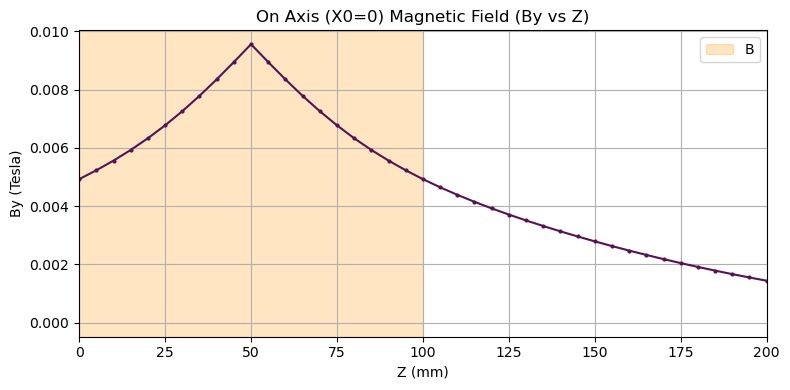

In [59]:
def fieldEvolution():
    """ 
    Evolution of the magnetic field across elements, plotted. 
    
    """
    # Load file, skipping comment lines
    with open("field_cellB.dat") as f:
        lines = f.readlines()[4:]
    
    data = np.array([[float(x) for x in line.split()] for line in lines])
    print(data)
    
    # If the file has columns: x y z Bx By Bz
    # then we can extract:
    z = data[:, 2]
    by = data[:, 4]
    
    
    # Draw shaded regions for magnets
    # Read your g4bl file
    with open("G4_FinalCooling_dispsup_B_opt.g4bl") as f:
        text = f.read()

    # Extract magnets (dipoles, quads, drifts, etc.)
    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))
    
    # Convert numeric values
    params = {k: float(v) for k, v in entries.items()}
    print(params)
    magnet_colors = {
            "B":     "#FFAA33",   # warm orange
        }

    regions = []
    length = optim_result.x[1]
    z1 = 0.0
    z2 = length
    regions.append((z1, z2, "#FFAA33", "B"))

    plt.figure(figsize=(8, 4))
    for z1, z2, color, label in regions:
        if z1 is not None and z2 is not None:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)
    
    plt.plot(z, by, '-o', color="#541352FF", markersize=2)
    plt.xlim(0.0, optim_result.x[1] * 2)
    plt.xlabel("Z (mm)")
    plt.ylabel("By (Tesla)")
    plt.title("On Axis (X0=0) Magnetic Field (By vs Z)")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig("Bfields.png")

fieldEvolution()

In [60]:
def parse_g4bl_file(filename):
    with open(filename) as f:
        text = f.read()

    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))

    return {k: float(v) for k, v in entries.items()}

def build_magnet_regions():
    regions = []
    length = optim_result.x[1]
    z1 = 0.0
    z2 = length
    regions.append((z1, z2, "#FFAA33", "B"))

    return regions

In [61]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))

        # ---- draw magnet shading (already parsed) ----
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # ---- twiss curves ----
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # ---- remove duplicate legend entries ----
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()


    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = ["particles_afterupt.txt", "particles_after_b.txt"]
z_positions = []
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y= []
alpha_x=[]
alpha_y=[]
D_x=[]
Dp_x=[]
D_y=[]
Dp_y=[]

for i in files:
        df1 = read_trackfile(i)
        z_positions.append(np.mean(df1["z"]))
        x_params1, y_params1, z_emit1 = calc_all_params(df1)
        ex, bx, gx, ax, Dx, Dxp = x_params1
        ey, by, gy, ay, Dy, Dyp = y_params1
        emit_x.append(ex)
        emit_y.append(ey)
        beta_x.append(bx)
        beta_y.append(by)
        alpha_x.append(ax)
        alpha_y.append(ay)
        D_x.append(Dx), Dp_x.append(Dxp), D_y.append(Dy), Dp_y.append(Dyp)
        emit_z.append(z_emit1)

g4bl_files = ["G4_FinalCooling_dispsup_B_run.g4bl"]

params = {}
for f in g4bl_files:
    params.update(parse_g4bl_file(f))

regions = build_magnet_regions()


twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y)

All plots saved in './dispsup_plots'


## Scrap

# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [ ]:
drift_length = 16000
rf_freq = 0.025

# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    drift_to_start = drift_length-rf_length/2
    post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
    post_cavity = run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))
    pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
    return np.std(p_total(cut_pz(pre_w2)))

# Run optimization
optim_result = minimize(func, [0, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")

# Runs a single case with the optimal parameters and add the transverse back in
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
post_cavity = cut_pz(recenter_t(run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad)))
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print_all_params(pre_w2)

# Second wedge

Optimize the second wedge in the same way as the first

In [ ]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4